# 3 * Land Cover Classification — Prédiction sur nouvelle image


In [2]:
import os
# Voir tous les fichiers dans tes datasets
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/hamzaessoussi/toulouse/sentinel2_toulouse_2023.tif
/kaggle/input/datasets/hamzaessoussi/mon-modele/means.npy
/kaggle/input/datasets/hamzaessoussi/mon-modele/stds.npy
/kaggle/input/datasets/hamzaessoussi/mon-modele/unet_best.pth
/kaggle/input/datasets/hamzaessoussi/nouvelle-image/sentinel2_alger_2023.tif


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.

Prédiction: 100%|██████████| 34/34 [00:32<00:00,  1.05it/s]


✅ Prédiction terminée !

  Distribution des classes prédites :
  0 Urbain          : 8.1%
  1 Végétation      : 32.3%
  2 Eau             : 54.8%
  3 Sol nu          : 0.1%
  4 Agriculture     : 4.3%
  5 Désert/Sable    : 0.4%
✅ RGB chargé


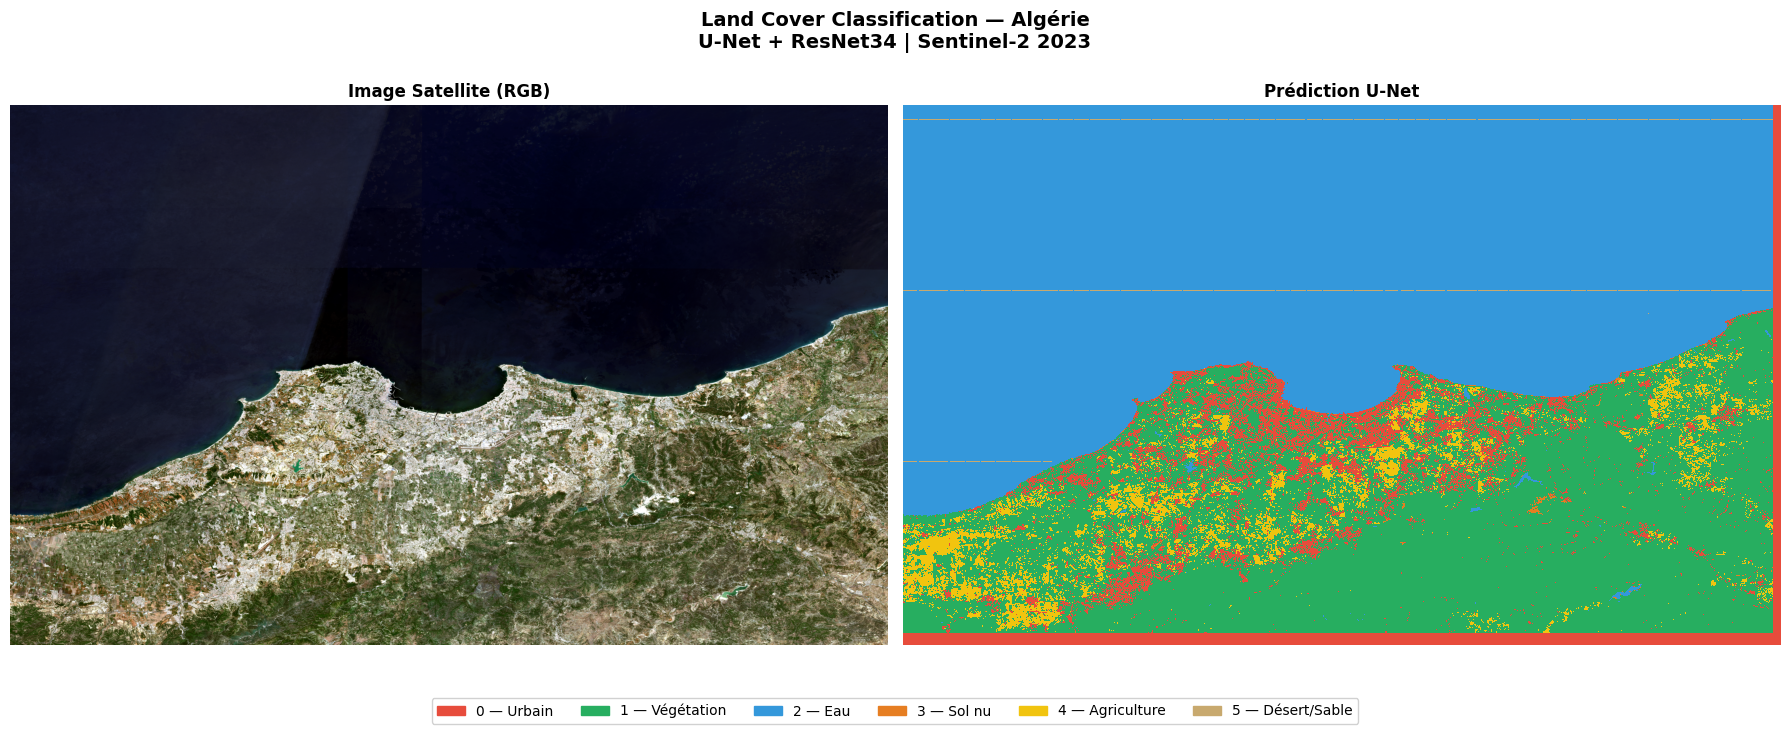

✅ Carte sauvegardée !


In [1]:

# ── Installation ─────────────────────────────────────────────────
!pip install rasterio segmentation-models-pytorch albumentations -q

import os, torch
import numpy as np
import rasterio
from rasterio.windows import Window
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm

# ── Config ───────────────────────────────────────────────────────
N_BANDS      = 10
N_CLASSES    = 6
PATCH_SIZE   = 128
CLASSES      = {0:'Urbain', 1:'Végétation', 2:'Eau', 3:'Sol nu', 4:'Agriculture', 5:'Désert/Sable'}
CLASS_COLORS = ['#E74C3C','#27AE60','#3498DB','#E67E22','#F1C40F','#C8A96E']
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

# ── Chemins ──────────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/datasets/hamzaessoussi/mon-modele/unet_best.pth"
MEANS_PATH = "/kaggle/input/datasets/hamzaessoussi/mon-modele/means.npy"
STDS_PATH  = "/kaggle/input/datasets/hamzaessoussi/mon-modele/stds.npy"
IMAGE_PATH = "/kaggle/input/datasets/hamzaessoussi/nouvelle-image/sentinel2_alger_2023.tif"

# ── Charger MEANS/STDS ────────────────────────────────────────────
MEANS = np.load(MEANS_PATH)
STDS  = np.load(STDS_PATH)
print("✅ MEANS/STDS chargés")

# ── Charger le modèle ─────────────────────────────────────────────
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = None,
    in_channels     = N_BANDS,
    classes         = N_CLASSES,
    activation      = None
)

# Supprimer le préfixe "module." ajouté par DataParallel
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)
model.eval()
model = model.to(DEVICE)
print("✅ Modèle chargé !")

# ── Vérifier l'image ─────────────────────────────────────────────
with rasterio.open(IMAGE_PATH) as src:
    print(f"✅ Image : {src.width} × {src.height} px | {src.count} bandes")
    H, W = src.height, src.width

# ── Prédiction ───────────────────────────────────────────────────
print("🗺️  Génération de la carte...")
full_pred = np.zeros((H, W), dtype=np.uint8)

with rasterio.open(IMAGE_PATH) as src:
    with torch.no_grad():
        for row in tqdm(range(0, H - PATCH_SIZE, PATCH_SIZE), desc="Prédiction"):
            for col in range(0, W - PATCH_SIZE, PATCH_SIZE):
                window    = Window(col, row, PATCH_SIZE, PATCH_SIZE)
                img_patch = src.read(window=window).astype(np.float32)
                img_patch = (img_patch - MEANS.reshape(-1,1,1)) / (STDS.reshape(-1,1,1) + 1e-8)
                tensor    = torch.from_numpy(img_patch).unsqueeze(0).to(DEVICE)
                pred      = model(tensor).argmax(dim=1).squeeze().cpu().numpy()
                full_pred[row:row+PATCH_SIZE, col:col+PATCH_SIZE] = pred

print("✅ Prédiction terminée !")

# Distribution
print("\n  Distribution des classes prédites :")
for cls_id, cls_name in CLASSES.items():
    pct = 100 * np.sum(full_pred == cls_id) / full_pred.size
    print(f"  {cls_id} {cls_name:<15} : {pct:.1f}%")

# ── RGB ──────────────────────────────────────────────────────────
def normalize_display(band):
    valid = band[band > 0]
    if len(valid) == 0: return band
    lo, hi = np.percentile(valid, [2, 98])
    return np.clip((band - lo) / (hi - lo + 1e-8), 0, 1)

with rasterio.open(IMAGE_PATH) as src:
    r = src.read(3).astype(float)
    g = src.read(2).astype(float)
    b = src.read(1).astype(float)
rgb = np.dstack([normalize_display(r), normalize_display(g), normalize_display(b)])
print("✅ RGB chargé")

# ── Visualisation ─────────────────────────────────────────────────
cmap_pred = mcolors.ListedColormap(CLASS_COLORS)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(rgb)
axes[0].set_title('Image Satellite (RGB)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(full_pred, cmap=cmap_pred, vmin=0, vmax=5, interpolation='nearest')
axes[1].set_title('Prédiction U-Net', fontsize=12, fontweight='bold')
axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i], label=f"{i} — {CLASSES[i]}")
           for i in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Land Cover Classification — Algérie\nU-Net + ResNet34 | Sentinel-2 2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_algerie.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ Carte sauvegardée !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompati

Prédiction: 100%|██████████| 30/30 [00:33<00:00,  1.12s/it]


✅ Prédiction terminée !

  Distribution des classes prédites :
  0 Urbain          : 4.3%
  1 Végétation      : 60.6%
  2 Eau             : 0.9%
  3 Sol nu          : 0.0%
  4 Agriculture     : 34.1%
  5 Désert/Sable    : 0.0%
✅ RGB chargé


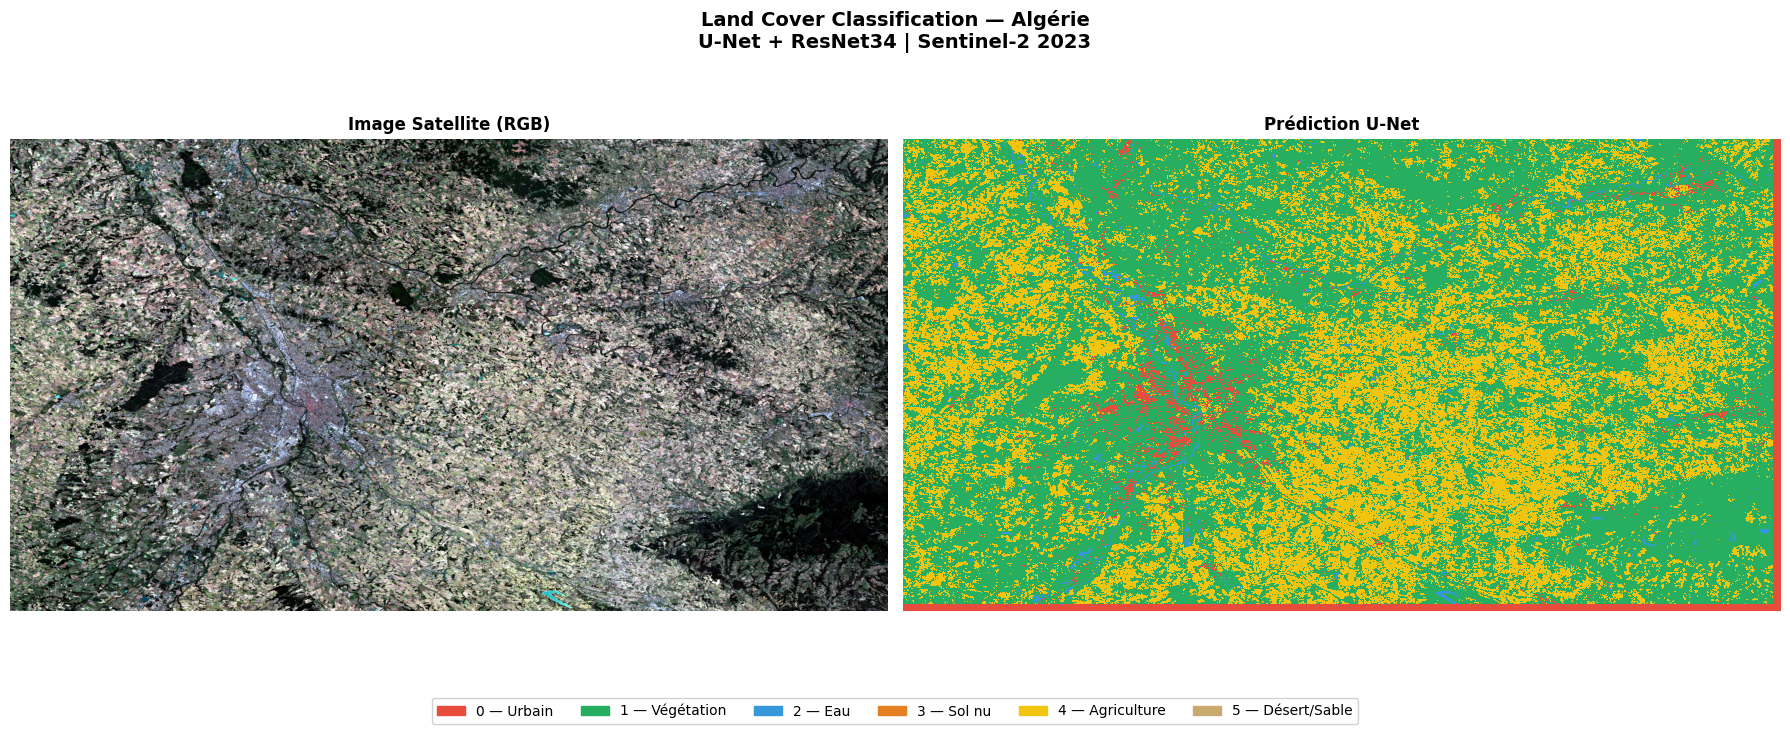

✅ Carte sauvegardée !


In [5]:

# ── Installation ─────────────────────────────────────────────────
!pip install rasterio segmentation-models-pytorch albumentations -q

import os, torch
import numpy as np
import rasterio
from rasterio.windows import Window
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm

# ── Config ───────────────────────────────────────────────────────
N_BANDS      = 10
N_CLASSES    = 6
PATCH_SIZE   = 128
CLASSES      = {0:'Urbain', 1:'Végétation', 2:'Eau', 3:'Sol nu', 4:'Agriculture', 5:'Désert/Sable'}
CLASS_COLORS = ['#E74C3C','#27AE60','#3498DB','#E67E22','#F1C40F','#C8A96E']
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

# ── Chemins ──────────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/datasets/hamzaessoussi/mon-modele/unet_best.pth"
MEANS_PATH = "/kaggle/input/datasets/hamzaessoussi/mon-modele/means.npy"
STDS_PATH  = "/kaggle/input/datasets/hamzaessoussi/mon-modele/stds.npy"
IMAGE_PATH = "/kaggle/input/datasets/hamzaessoussi/toulouse/sentinel2_toulouse_2023.tif"

# ── Charger MEANS/STDS ────────────────────────────────────────────
MEANS = np.load(MEANS_PATH)
STDS  = np.load(STDS_PATH)
print("✅ MEANS/STDS chargés")

# ── Charger le modèle ─────────────────────────────────────────────
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = None,
    in_channels     = N_BANDS,
    classes         = N_CLASSES,
    activation      = None
)

# Supprimer le préfixe "module." ajouté par DataParallel
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)
model.eval()
model = model.to(DEVICE)
print("✅ Modèle chargé !")

# ── Vérifier l'image ─────────────────────────────────────────────
with rasterio.open(IMAGE_PATH) as src:
    print(f"✅ Image : {src.width} × {src.height} px | {src.count} bandes")
    H, W = src.height, src.width

# ── Prédiction ───────────────────────────────────────────────────
print("🗺️  Génération de la carte...")
full_pred = np.zeros((H, W), dtype=np.uint8)

with rasterio.open(IMAGE_PATH) as src:
    with torch.no_grad():
        for row in tqdm(range(0, H - PATCH_SIZE, PATCH_SIZE), desc="Prédiction"):
            for col in range(0, W - PATCH_SIZE, PATCH_SIZE):
                window    = Window(col, row, PATCH_SIZE, PATCH_SIZE)
                img_patch = src.read(window=window).astype(np.float32)
                img_patch = (img_patch - MEANS.reshape(-1,1,1)) / (STDS.reshape(-1,1,1) + 1e-8)
                tensor    = torch.from_numpy(img_patch).unsqueeze(0).to(DEVICE)
                pred      = model(tensor).argmax(dim=1).squeeze().cpu().numpy()
                full_pred[row:row+PATCH_SIZE, col:col+PATCH_SIZE] = pred

print("✅ Prédiction terminée !")

# Distribution
print("\n  Distribution des classes prédites :")
for cls_id, cls_name in CLASSES.items():
    pct = 100 * np.sum(full_pred == cls_id) / full_pred.size
    print(f"  {cls_id} {cls_name:<15} : {pct:.1f}%")

# ── RGB ──────────────────────────────────────────────────────────
def normalize_display(band):
    valid = band[band > 0]
    if len(valid) == 0: return band
    lo, hi = np.percentile(valid, [2, 98])
    return np.clip((band - lo) / (hi - lo + 1e-8), 0, 1)

with rasterio.open(IMAGE_PATH) as src:
    r = src.read(3).astype(float)
    g = src.read(2).astype(float)
    b = src.read(1).astype(float)
rgb = np.dstack([normalize_display(r), normalize_display(g), normalize_display(b)])
print("✅ RGB chargé")

# ── Visualisation ─────────────────────────────────────────────────
cmap_pred = mcolors.ListedColormap(CLASS_COLORS)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(rgb)
axes[0].set_title('Image Satellite (RGB)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(full_pred, cmap=cmap_pred, vmin=0, vmax=5, interpolation='nearest')
axes[1].set_title('Prédiction U-Net', fontsize=12, fontweight='bold')
axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i], label=f"{i} — {CLASSES[i]}")
           for i in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Land Cover Classification — Algérie\nU-Net + ResNet34 | Sentinel-2 2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_TOulouse.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ Carte sauvegardée !")

In [7]:
import os
import rasterio

FILE_PATH = "/kaggle/input/datasets/hamzaessoussi/toulouse/sentinel2_toulouse_2023.tif"

# Vérifier la taille
size_mb = os.path.getsize(FILE_PATH) / 1e6
print(f"Taille : {size_mb:.0f} MB")

# Tester l'ouverture
try:
    with rasterio.open(FILE_PATH) as src:
        print(f"Dimensions : {src.width} × {src.height}")
        print(f"Bandes : {src.count}")
        # Lire le premier bloc pour tester
        test = src.read(1, window=rasterio.windows.Window(0, 0, 128, 128))
        print("✅ Fichier lisible !")
except Exception as e:
    print(f"❌ Fichier corrompu : {e}")

Taille : 1226 MB
Dimensions : 7237 × 3897
Bandes : 10
✅ Fichier lisible !
